In [1]:
# !pip install catboost

# !pip install optuna

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier
import catboost as cb
from catboost import CatBoostClassifier, Pool
import optuna

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/2차프로젝트/data_v2.csv')
df.head(5)

,yqc_cd,year,quarter,ds,gu_cd,gu_nm,dong_cd,dong_nm,dong_area,business_cd,...,SEL_close_avg,wp_total,rp_total,apt_cnt,apt_price,business_cat,wp_missing,rp_missing,apt_cnt_missing,apt_price_missing
0,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,48,6476,13047,342,243371110,음식(한식),0,0,1,1
1,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100002,...,48,6476,13047,342,243371110,음식(중식),0,0,1,1
2,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100003,...,48,6476,13047,342,243371110,음식(일식),0,0,1,1
3,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100004,...,48,6476,13047,342,243371110,음식(양식),0,0,1,1
4,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100005,...,48,6476,13047,342,243371110,음식(빵집),0,0,1,1


### EDA

Step 1. 시계열 패널 데이터 연속성 확인

전체 상권-업종 조합 수: 19018
총 24개 분기가 모두 존재하는 조합의 비율: 74.66%


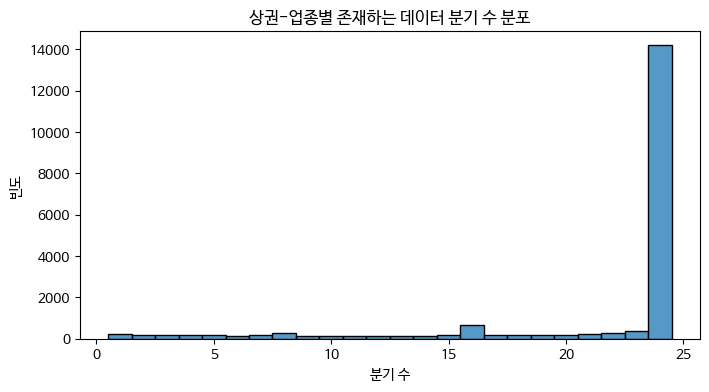

In [4]:
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 행정동(dong_cd)과 업종(business_cd) 조합별로 데이터가 존재하는 분기(yqc_cd) 수 확인
continuity_check = df.groupby(['dong_cd', 'business_cd'])['yqc_cd'].nunique()

print("전체 상권-업종 조합 수:", len(continuity_check))
print("총 24개 분기가 모두 존재하는 조합의 비율: {:.2f}%".format((continuity_check == 24).mean() * 100))

# 24개 분기가 안 되는(중간에 생기거나 폐업한) 조합이 얼마나 되는지 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(continuity_check, bins=24, discrete=True)
plt.title("상권-업종별 존재하는 데이터 분기 수 분포")
plt.xlabel("분기 수")
plt.ylabel("빈도")
plt.show()

Step 2. 전체 기간 매출 트렌드 (코로나 및 계절성 파악)

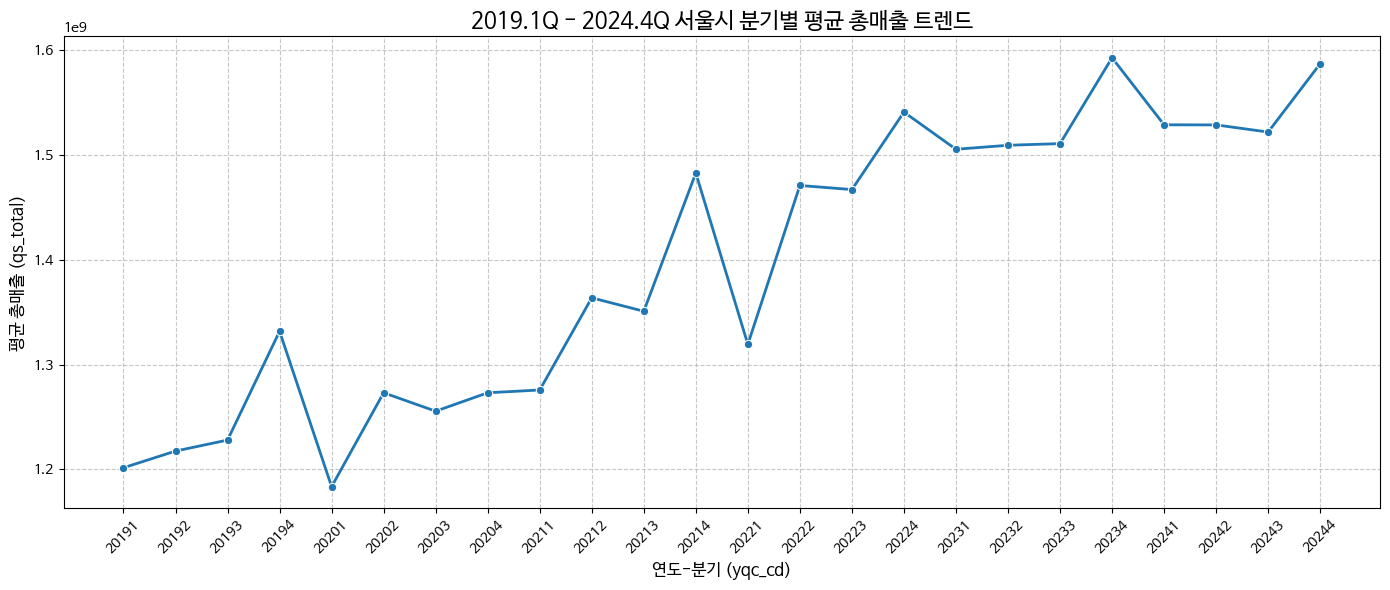

In [5]:
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 분기별 평균 총매출 집계
trend_df = df.groupby('yqc_cd')['qs_total'].mean().reset_index()

plt.figure(figsize=(14, 6))
# yqc_cd를 문자열로 변환하여 x축이 깔끔하게 나오도록 함
sns.lineplot(data=trend_df, x=trend_df['yqc_cd'].astype(str), y='qs_total', marker='o', linewidth=2)

plt.title("2019.1Q - 2024.4Q 서울시 분기별 평균 총매출 트렌드", fontsize=16)
plt.xlabel("연도-분기 (yqc_cd)", fontsize=12)
plt.ylabel("평균 총매출 (qs_total)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Step 3. '성장/유지/위축' 라벨링을 위한 증감률 기준선 찾기

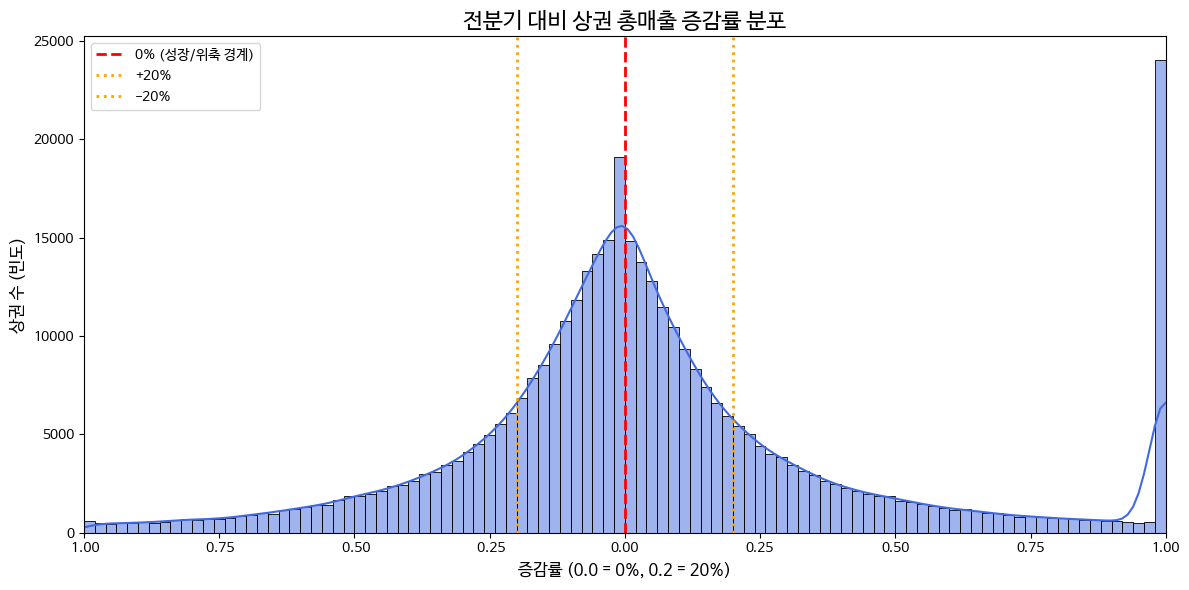

=== 매출 증감률 주요 통계량 ===
count    385205.000000
mean          3.026195
std         665.584359
min          -0.999998
10%          -0.359209
25%          -0.141287
50%           0.002650
75%           0.191246
90%           0.608683
max      371900.740525
Name: growth_rate, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 경고문 무시
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 1. 데이터 정렬 및 복사 (SettingWithCopyWarning 방지)
df = df.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).copy()

# 2. 전분기 대비 매출 증감률(growth_rate) 계산
df['growth_rate'] = df.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()

# 3. 분석을 위한 데이터 정제 (무한대 값과 결측치 제거)
df['growth_rate'] = df['growth_rate'].replace([np.inf, -np.inf], np.nan)
growth_data = df.dropna(subset=['growth_rate'])['growth_rate']

# 4. 히스토그램 시각화 (극단적인 이상치를 제외하고 -100% ~ +100% 구간만 확대)
plt.figure(figsize=(12, 6))
# 데이터가 너무 많을 경우를 대비해 구간(bins)을 세밀하게 나눔
sns.histplot(growth_data.clip(-1, 1), bins=100, kde=True, color='royalblue')

# 기준선 표시 (0%)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0% (성장/위축 경계)')
plt.axvline(x=0.2, color='orange', linestyle=':', linewidth=2, label='+20%')
plt.axvline(x=-0.2, color='orange', linestyle=':', linewidth=2, label='-20%')

plt.title("전분기 대비 상권 총매출 증감률 분포", fontsize=16)
plt.xlabel("증감률 (0.0 = 0%, 0.2 = 20%)", fontsize=12)
plt.ylabel("상권 수 (빈도)", fontsize=12)
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

# 5. 주요 통계량 확인
print("=== 매출 증감률 주요 통계량 ===")
print(growth_data.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

### Feature Engineering

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_feat = df.copy()

# ==========================================
# [1] 기본 스케일 변수 (로그 변환)
# ==========================================
log_cols = ['qs_total', 'fp_total', 'wp_total', 'rp_total', 'apt_price', 'subway_station', 'bus_station']
for col in log_cols:
    df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# ==========================================
# [2] 상권 경쟁력 및 효율 지표
# ==========================================
safe_store_cnt = df_feat['similar_store_cnt'].replace(0, 1)
df_feat['sales_per_store'] = df_feat['qs_total'] / safe_store_cnt
df_feat['store_density'] = df_feat['similar_store_cnt'] / df_feat['dong_area']
df_feat['ATV'] = (df_feat['qs_total'] / df_feat['qsc_total'].replace(0, 1)).fillna(0)

# ==========================================
# [3] 시간대/요일/연령대 비율 (폭넓게 모두 추가!)
# ==========================================
safe_qs_total = df_feat['qs_total'].replace(0, 1)

# 요일 비중
df_feat['sales_weekdays_ratio'] = df_feat['qs_weekdays'] / safe_qs_total
df_feat['sales_weekend_ratio'] = df_feat['qs_weekend'] / safe_qs_total

# 시간대 비중
df_feat['sales_lunch_ratio'] = df_feat['qs_1114'] / safe_qs_total   # 점심
df_feat['sales_afternoon_ratio'] = df_feat['qs_1417'] / safe_qs_total # 오후
df_feat['sales_evening_ratio'] = df_feat['qs_1721'] / safe_qs_total # 저녁 (퇴근/회식)
df_feat['sales_night_ratio'] = df_feat['qs_2124'] / safe_qs_total   # 심야 (유흥)

# 연령대 비중
df_feat['sales_2030_ratio'] = (df_feat['qs_20'] + df_feat['qs_30']) / safe_qs_total # 트렌드 주도층
df_feat['sales_3050_ratio'] = (df_feat['qs_30'] + df_feat['qs_40'] + df_feat['qs_50']) / safe_qs_total # 머니 파워 (직장인/가족)
df_feat['sales_60_ratio'] = df_feat['qs_60'] / safe_qs_total # 시니어

# ==========================================
# [4] 인프라 지표
# ==========================================
df_feat['is_univ'] = (df_feat['university'] > 0).astype(int)
df_feat['edu_cnt'] = df_feat['kindergarden'] + df_feat['ele_school'] + df_feat['mid_school'] + df_feat['high_school']
df_feat['traffic_score'] = (df_feat['subway_station_log'] * 3) + df_feat['bus_station_log']

In [8]:
df_feat.head(5)

,yqc_cd,year,quarter,ds,gu_cd,gu_nm,dong_cd,dong_nm,dong_area,business_cd,...,sales_lunch_ratio,sales_afternoon_ratio,sales_evening_ratio,sales_night_ratio,sales_2030_ratio,sales_3050_ratio,sales_60_ratio,is_univ,edu_cnt,traffic_score
0,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,0.341954,0.108466,0.339677,0.161194,0.318089,0.528391,0.081971,1,6,3.295837
16050,20192,2019,2,2019-06-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,0.357197,0.101477,0.342767,0.150563,0.319993,0.525832,0.107766,1,6,3.295837
32235,20193,2019,3,2019-09-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,0.362353,0.097503,0.346854,0.147596,0.323724,0.515234,0.116989,1,6,3.295837
48452,20194,2019,4,2019-12-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,0.304598,0.096200,0.370518,0.147147,0.317732,0.480645,0.112008,1,6,3.295837
64727,20201,2020,1,2020-03-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,0.315146,0.094957,0.357403,0.142621,0.341881,0.529797,0.109664,1,6,3.295837


In [9]:
# ==========================================
# [5] 시계열 파생 변수 생성
# ==========================================
# 1. 데이터 시간순 정렬 (그룹별 시계열 연산 필수)
df_feat = df_feat.sort_values(by=['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 2. 파생 변수를 만들 핵심 타겟 변수들 (상위 중요도 피처 위주)
target_cols = ['qs_total_log', 'sales_per_store', 'ATV', 'fp_total_log', 'store_density']

# 3. 동 + 업종별 그룹바이
grouped = df_feat.groupby(['dong_cd', 'business_cd'])

for col in target_cols:
    # [1] 단기 모멘텀 (2분기)
    df_feat[f'{col}_MA2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
    df_feat[f'{col}_STD2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=2).std()).fillna(0)

    # [2] 장기/계절성 트렌드 (4분기)
    df_feat[f'{col}_MA4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
    df_feat[f'{col}_STD4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=2).std()).fillna(0)

    # [3] 전분기 대비 증감률 (QoQ) - (현재 - 과거) / 과거
    df_feat[f'{col}_QoQ'] = grouped[col].transform(lambda x: (x - x.shift(1)) / (x.shift(1) + 1e-5)).fillna(0)

# 4. 계절성(Quarter) 피처 추출 (1~4분기 범주화)
df_feat['quarter'] = (df_feat['yqc_cd'] % 10).astype(int)

print("=== 파생 변수 생성 완료 ===")
print(f"새로 추가된 컬럼 수: {len(target_cols) * 5 + 1}개")

display(df_feat[['dong_cd', 'business_cd', 'yqc_cd', 'ATV', 'ATV_MA2', 'ATV_MA4', 'ATV_QoQ']].head())

=== 파생 변수 생성 완료 ===
새로 추가된 컬럼 수: 26개


,dong_cd,business_cd,yqc_cd,ATV,ATV_MA2,ATV_MA4,ATV_QoQ
0,11110515,CS100001,20191,29288.696246,29288.696246,29288.696246,0.000000
1,11110515,CS100001,20192,27924.413127,28606.554687,28606.554687,-0.046581
2,11110515,CS100001,20193,27091.115348,27507.764238,28101.408241,-0.029841
3,11110515,CS100001,20194,30659.810868,28875.463108,28741.008897,0.131729
4,11110515,CS100001,20201,29206.011081,29932.910975,28720.337606,-0.047417


In [10]:
# ==========================================
# [6] 상권 특성 클러스터링 (K-Means)
# ==========================================
# 클러스터링에 사용할 비율 데이터들만 추출
cluster_features = [
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio'
]

# K-Means는 거리를 기반으로 하므로 스케일링 필수
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_feat[cluster_features].fillna(0))

# 군집 개수는 임의로 4개로 설정 (예: 직장인상권, 대학가/유흥상권, 주거지상권, 기타)
kmeans = KMeans(n_clusters=4, random_state=42)
df_feat['cluster_id'] = kmeans.fit_predict(scaled_data)

# 결과 확인 (직접 눈으로 뜯어보기)
print("=== 클러스터별 상권-분기 데이터 개수 ===")
print(df_feat['cluster_id'].value_counts().sort_index())

print("\n=== 클러스터별 주요 피처 평균값 ===")
cluster_means = df_feat.groupby('cluster_id')[cluster_features].mean()

display(cluster_means.round(3))

=== 클러스터별 상권-분기 데이터 개수 ===
cluster_id
0     63114
1    150084
2     65795
3    125230
Name: count, dtype: int64

=== 클러스터별 주요 피처 평균값 ===


,sales_weekdays_ratio,sales_weekend_ratio,sales_lunch_ratio,sales_evening_ratio,sales_night_ratio,sales_2030_ratio,sales_3050_ratio
cluster_id,,,,,,,
0,0.918,0.082,0.129,0.442,0.047,0.259,0.807
1,0.659,0.341,0.250,0.347,0.050,0.314,0.634
2,0.687,0.313,0.070,0.327,0.320,0.412,0.614
3,0.870,0.130,0.340,0.177,0.012,0.181,0.516


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [11]:
df_feat['cluster_id']

,cluster_id
0,1
1,1
2,1
3,1
4,1
...,...
404218,1
404219,3
404220,3
404221,1


In [12]:
print(df_feat.columns.tolist())

['yqc_cd', 'year', 'quarter', 'ds', 'gu_cd', 'gu_nm', 'dong_cd', 'dong_nm', 'dong_area', 'business_cd', 'business_nm', 'qs_total', 'qsc_total', 'qs_weekdays', 'qs_weekend', 'qs_mon', 'qs_tue', 'qs_wed', 'qs_thu', 'qs_fri', 'qs_sat', 'qs_sun', 'qs_0006', 'qs_0611', 'qs_1114', 'qs_1417', 'qs_1721', 'qs_2124', 'qs_m', 'qs_w', 'qs_10', 'qs_20', 'qs_30', 'qs_40', 'qs_50', 'qs_60', 'qsc_weekdays', 'qsc_weekend', 'qsc_mon', 'qsc_tue', 'qsc_wed', 'qsc_thu', 'qsc_fri', 'qsc_sat', 'qsc_sun', 'qsc_0006', 'qsc_0611', 'qsc_1114', 'qsc_1417', 'qsc_1721', 'qsc_2124', 'qsc_m', 'qsc_w', 'qsc_10', 'qsc_20', 'qsc_30', 'qsc_40', 'qsc_50', 'qsc_60', 'store_cnt', 'similar_store_cnt', 'open_rate', 'open_cnt', 'close_rate', 'close_cnt', 'frn_store_cnt', 'government', 'bank', 'gen_hospital', 'hospital', 'phamacy', 'kindergarden', 'ele_school', 'mid_school', 'high_school', 'university', 'department', 'supermarket', 'theater', 'accommodation', 'airport', 'railway', 'bus_terminal', 'subway_station', 'bus_station'

In [13]:
# ==========================================
# [7] 모델에 넣을 임시 피처 리스트 총망라
# ==========================================
final_features = [
    'yqc_cd', 'dong_cd', 'business_cd',
    'qs_total_log', 'fp_total_log', 'wp_total_log', 'rp_total_log', 'apt_price_log',
    'sales_per_store', 'store_density', 'ATV',
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_afternoon_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio', 'sales_60_ratio',
    'is_univ', 'edu_cnt', 'traffic_score',
    'qs_total_log_MA2', 'qs_total_log_STD2', 'qs_total_log_MA4', 'qs_total_log_STD4', 'qs_total_log_QoQ',
    'sales_per_store_MA2', 'sales_per_store_STD2', 'sales_per_store_MA4', 'sales_per_store_STD4', 'sales_per_store_QoQ',
    'ATV_MA2', 'ATV_STD2', 'ATV_MA4', 'ATV_STD4', 'ATV_QoQ',
    'fp_total_log_MA2', 'fp_total_log_STD2', 'fp_total_log_MA4', 'fp_total_log_STD4', 'fp_total_log_QoQ',
    'store_density_MA2', 'store_density_STD2', 'store_density_MA4', 'store_density_STD4', 'store_density_QoQ',
    'cluster_id'
]

df_final = df_feat[final_features].copy()

print("=== 피처 엔지니어링 & 클러스터링 완료 ===")
print("총 피처 개수:", len(final_features) - 3) # 식별자 3개 제외
print("\n[상권 클러스터 분포]")
print(df_final['cluster_id'].value_counts())

=== 피처 엔지니어링 & 클러스터링 완료 ===
총 피처 개수: 46

[상권 클러스터 분포]
cluster_id
1    150084
3    125230
2     65795
0     63114
Name: count, dtype: int64


####Sliding Window (과거 데이터 시프트)

$t$ 분기의 타겟(성장/유지/위축)을 예측하기 위해, 모델의 입력(Input) 피처들은 전부 $t-1$ 분기(또는 그 이전)의 데이터를 바라보도록 짝을 맞춰주는 작업

In [14]:
# 1. 데이터 정렬 (누수 방지의 핵심: 상권별, 업종별, 시간순으로 반드시 정렬)
df_feat = df_feat.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)
df_final = df_final.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 2. 타겟(Target) 생성 (원본 데이터인 df_feat에서 qs_total을 이용해 계산)
# 전분기 대비 매출 증감률 계산
df_feat['growth_rate'] = df_feat.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()
df_feat['growth_rate'] = df_feat['growth_rate'].replace([np.inf, -np.inf], np.nan)

# ±20% 기준으로 위축(0), 유지(1), 성장(2) 라벨링
df_final['target'] = pd.cut(
    df_feat['growth_rate'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=[0, 1, 2]
)

# 3. Shift(한 칸 밀기)를 적용할 피처 리스트 뽑기
# 식별자(상권, 업종, 시간)는 밀면 안 되니까 제외.
shift_cols = [col for col in df_final.columns if col not in ['yqc_cd', 'dong_cd', 'business_cd', 'target']]

# 4. Sliding Window (Shift) 적용
df_shifted = df_final.copy()
for col in shift_cols:
    # 상권-업종별로 묶은 뒤, 1분기 전의 데이터를 'prev_'라는 이름표를 붙여서 가져옴.
    df_shifted[f'prev_{col}'] = df_shifted.groupby(['dong_cd', 'business_cd'])[col].shift(1)

# 5. 변수 선택 이전 임시 데이터셋 조립 (식별자 + 타겟 + 과거 피처)
temp_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target'] + [f'prev_{col}' for col in shift_cols]
df_temp = df_shifted[temp_cols].copy()

# 6. 결측치 제거
# shift(1)을 했기 때문에 2019년 1분기(이전 데이터가 없는 분기) 등은 자연스럽게 NaN이 되어 떨어져 나감.
df_temp = df_temp.dropna().reset_index(drop=True)

print("=== 임시 데이터셋 (df_temp) 완성 ===")
print("데이터 쉐이프:", df_temp.shape)
print("\n[Target 클래스 비율 확인]")
print(df_temp['target'].value_counts(normalize=True).sort_index() * 100)

=== 임시 데이터셋 (df_temp) 완성 ===
데이터 쉐이프: (385205, 50)

[Target 클래스 비율 확인]
target
0    19.116055
1    56.526265
2    24.357680
Name: proportion, dtype: float64


In [15]:
df_temp.columns.tolist()

['dong_cd',
 'business_cd',
 'yqc_cd',
 'target',
 'prev_qs_total_log',
 'prev_fp_total_log',
 'prev_wp_total_log',
 'prev_rp_total_log',
 'prev_apt_price_log',
 'prev_sales_per_store',
 'prev_store_density',
 'prev_ATV',
 'prev_sales_weekdays_ratio',
 'prev_sales_weekend_ratio',
 'prev_sales_lunch_ratio',
 'prev_sales_afternoon_ratio',
 'prev_sales_evening_ratio',
 'prev_sales_night_ratio',
 'prev_sales_2030_ratio',
 'prev_sales_3050_ratio',
 'prev_sales_60_ratio',
 'prev_is_univ',
 'prev_edu_cnt',
 'prev_traffic_score',
 'prev_qs_total_log_MA2',
 'prev_qs_total_log_STD2',
 'prev_qs_total_log_MA4',
 'prev_qs_total_log_STD4',
 'prev_qs_total_log_QoQ',
 'prev_sales_per_store_MA2',
 'prev_sales_per_store_STD2',
 'prev_sales_per_store_MA4',
 'prev_sales_per_store_STD4',
 'prev_sales_per_store_QoQ',
 'prev_ATV_MA2',
 'prev_ATV_STD2',
 'prev_ATV_MA4',
 'prev_ATV_STD4',
 'prev_ATV_QoQ',
 'prev_fp_total_log_MA2',
 'prev_fp_total_log_STD2',
 'prev_fp_total_log_MA4',
 'prev_fp_total_log_STD4',


### 탐색적 가설 검정

In [16]:
from scipy import stats

# 1. 사용할 데이터프레임과 타겟 변수 설정
target_col = 'target'
df_test = df_temp.copy()

# 2. 피처 그룹핑
id_features = ['yqc_cd', 'dong_cd', 'business_cd']

cat_features = ['prev_is_univ', 'prev_cluster_id']

num_features = [
    'prev_qs_total_log', 'prev_fp_total_log', 'prev_wp_total_log', 'prev_rp_total_log', 'prev_apt_price_log',
    'prev_sales_per_store', 'prev_store_density', 'prev_ATV',
    'prev_sales_weekdays_ratio', 'prev_sales_weekend_ratio',
    'prev_sales_lunch_ratio', 'prev_sales_afternoon_ratio', 'prev_sales_evening_ratio', 'prev_sales_night_ratio',
    'prev_sales_2030_ratio', 'prev_sales_3050_ratio', 'prev_sales_60_ratio',
    'prev_edu_cnt', 'prev_traffic_score',

    # 시계열 파생 변수
    'prev_qs_total_log_MA2', 'prev_qs_total_log_STD2', 'prev_qs_total_log_MA4', 'prev_qs_total_log_STD4', 'prev_qs_total_log_QoQ',
    'prev_sales_per_store_MA2', 'prev_sales_per_store_STD2', 'prev_sales_per_store_MA4', 'prev_sales_per_store_STD4', 'prev_sales_per_store_QoQ',
    'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_MA4', 'prev_ATV_STD4', 'prev_ATV_QoQ',
    'prev_fp_total_log_MA2', 'prev_fp_total_log_STD2', 'prev_fp_total_log_MA4', 'prev_fp_total_log_STD4', 'prev_fp_total_log_QoQ',
    'prev_store_density_MA2', 'prev_store_density_STD2', 'prev_store_density_MA4', 'prev_store_density_STD4', 'prev_store_density_QoQ',
]

results = []

# 3. 연속형 변수 검정 (ANOVA)
for col in num_features:
    # df_model에 해당 컬럼이 있는지 확인 후 진행 (에러 방지)
    if col in df_test.columns:
        # 그룹별 데이터 추출
        groups = [df_test[df_test[target_col] == cls][col].dropna() for cls in df_test[target_col].dropna().unique()]

        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
            results.append({'Feature': col, 'Type': 'Numeric (ANOVA)', 'p-value': p_val, 'Significant': p_val < 0.05})

# 4. 범주형 변수 검정 (Chi-Square)
for col in cat_features:
    if col in df_test.columns:
        contingency_table = pd.crosstab(df_test[target_col], df_test[col])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        results.append({'Feature': col, 'Type': 'Categorical (Chi-Square)', 'p-value': p_val, 'Significant': p_val < 0.05})

# 5. 결과 정리 및 출력
df_test_results = pd.DataFrame(results)
df_test_results['p-value'] = df_test_results['p-value'].apply(lambda x: f"{x:.4f}")

print("=== 피처별 가설 검정 결과 ===")
display(df_test_results.sort_values(by=['Significant', 'Type'], ascending=[False, True]).reset_index(drop=True))

# 6. 최종 선택된 피처 리스트 도출
passed_features = df_test_results[df_test_results['Significant'] == True]['Feature'].tolist()
failed_features = df_test_results[df_test_results['Significant'] == False]['Feature'].tolist()

print(f"\n 통과된 피처 (모델 학습 후보): {len(passed_features)}개")
print(passed_features)
print(f"\n 탈락된 피처 (통계적 의미 없음): {len(failed_features)}개")
print(failed_features)

=== 피처별 가설 검정 결과 ===


,Feature,Type,p-value,Significant
0,prev_cluster_id,Categorical (Chi-Square),0.0000,True
1,prev_qs_total_log,Numeric (ANOVA),0.0000,True
2,prev_fp_total_log,Numeric (ANOVA),0.0000,True
3,prev_wp_total_log,Numeric (ANOVA),0.0000,True
4,prev_rp_total_log,Numeric (ANOVA),0.0000,True
5,prev_apt_price_log,Numeric (ANOVA),0.0000,True
6,prev_sales_per_store,Numeric (ANOVA),0.0000,True
7,prev_store_density,Numeric (ANOVA),0.0000,True
8,prev_ATV,Numeric (ANOVA),0.0000,True
9,prev_sales_weekdays_ratio,Numeric (ANOVA),0.0000,True



 통과된 피처 (모델 학습 후보): 44개
['prev_qs_total_log', 'prev_fp_total_log', 'prev_wp_total_log', 'prev_rp_total_log', 'prev_apt_price_log', 'prev_sales_per_store', 'prev_store_density', 'prev_ATV', 'prev_sales_weekdays_ratio', 'prev_sales_weekend_ratio', 'prev_sales_lunch_ratio', 'prev_sales_afternoon_ratio', 'prev_sales_evening_ratio', 'prev_sales_night_ratio', 'prev_sales_2030_ratio', 'prev_sales_3050_ratio', 'prev_sales_60_ratio', 'prev_edu_cnt', 'prev_traffic_score', 'prev_qs_total_log_MA2', 'prev_qs_total_log_STD2', 'prev_qs_total_log_MA4', 'prev_qs_total_log_STD4', 'prev_qs_total_log_QoQ', 'prev_sales_per_store_MA2', 'prev_sales_per_store_STD2', 'prev_sales_per_store_MA4', 'prev_sales_per_store_STD4', 'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_MA4', 'prev_ATV_STD4', 'prev_ATV_QoQ', 'prev_fp_total_log_MA2', 'prev_fp_total_log_STD2', 'prev_fp_total_log_MA4', 'prev_fp_total_log_STD4', 'prev_fp_total_log_QoQ', 'prev_store_density_MA2', 'prev_store_density_STD2', 'prev_store_density_MA4', 'pr

### VIF(다중공선성) 검사

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_sales_weekend_ratio,4.408090e+06
1,prev_sales_weekdays_ratio,4.408089e+06
2,prev_fp_total_log,2.549162e+05
3,prev_fp_total_log_MA2,2.526247e+05
4,prev_store_density_MA2,1.308718e+05
5,prev_store_density,5.782502e+04
6,prev_store_density_MA4,2.175519e+04
7,prev_qs_total_log_MA2,1.563230e+03
8,prev_qs_total_log,1.426068e+03
9,prev_fp_total_log_MA4,5.246303e+02


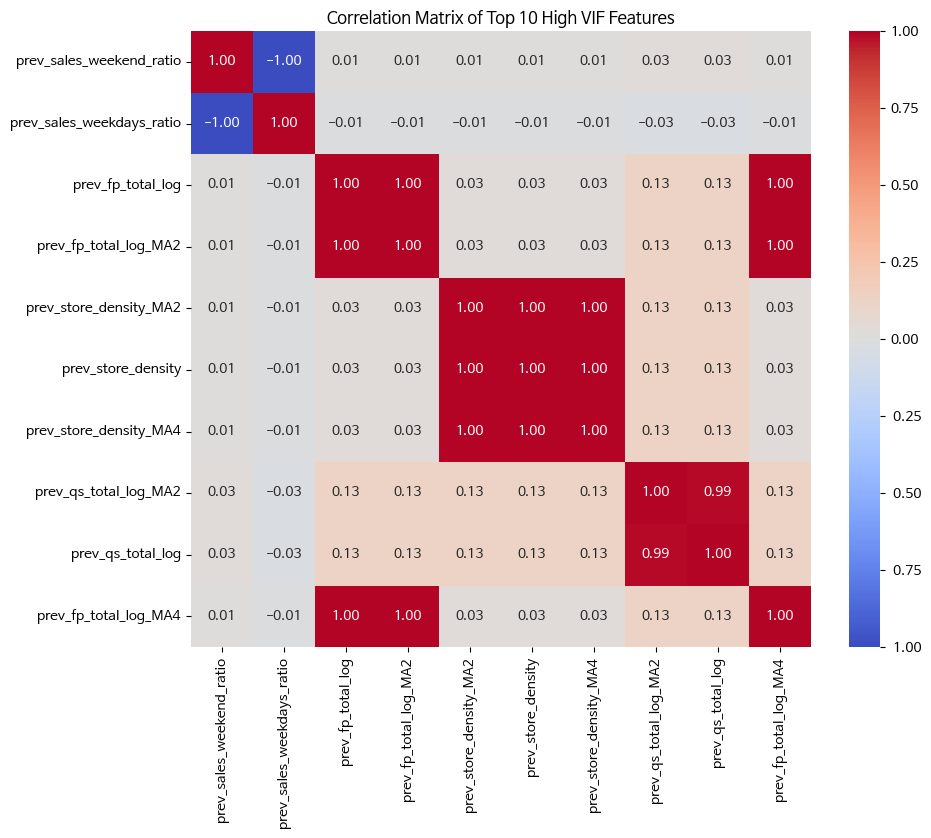

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. ANOVA/Chi-Square 통과한 피처들만 선택 (passed_features)
X_vif = df_temp[passed_features].copy()

# 2. VIF 계산을 위한 전처리
# VIF는 연속형 변수에 대해서만 계산하므로, 범주형 변수(cluster_id 등)가 섞여있다면 제외해야 함
# 데이터 타입이 숫자형인 것만 필터링하고 결측치 제거
X_vif_numeric = X_vif.select_dtypes(include=[np.number]).dropna()

# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif_numeric.insert(0, 'const', 1.0)

# 3. VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_numeric.values, i) for i in range(X_vif_numeric.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif_data.head(20)) # 너무 많을 수 있으니 상위 20개만 먼저 확인

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif_data['Feature'].head(10).tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(X_vif_numeric[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

### VIF 2차 검사

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_fp_total_log,252835.445417
1,prev_fp_total_log_MA2,252056.359670
2,prev_store_density_MA2,27567.838186
3,prev_store_density,27537.529288
4,prev_qs_total_log,1403.664714
5,prev_qs_total_log_MA2,1372.286102
6,prev_fp_total_log_QoQ,445.013829
7,prev_sales_per_store_MA2,43.188862
8,prev_sales_per_store,42.551999
9,prev_qs_total_log_QoQ,31.451856


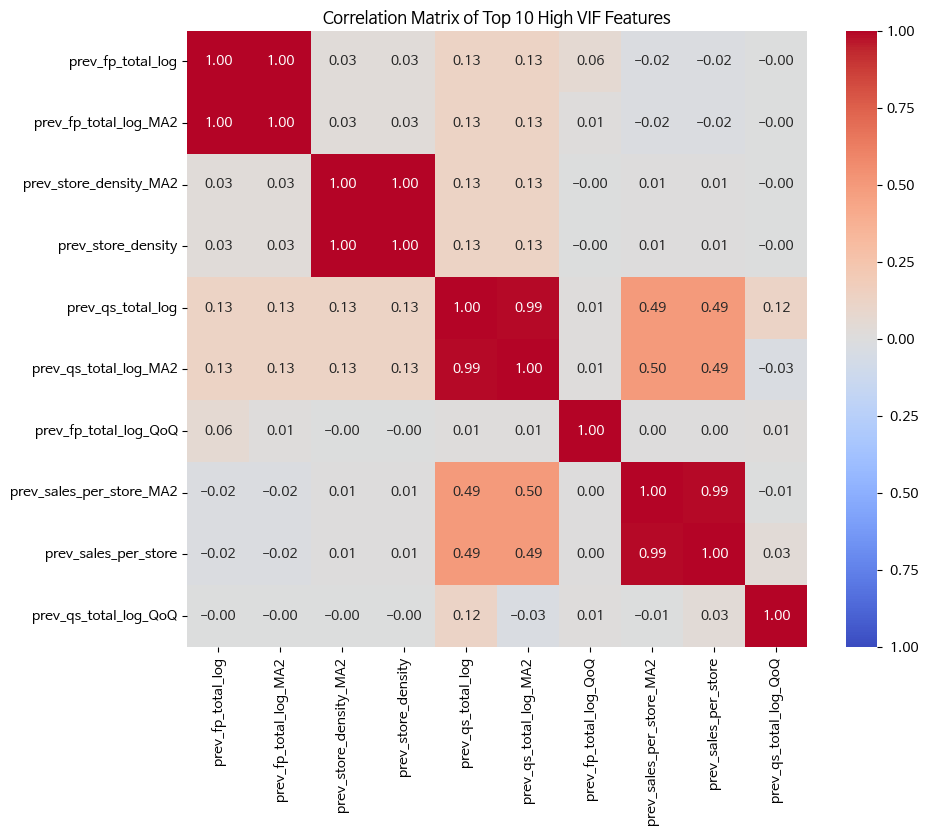

In [18]:
# 1. X_vif에서 VIF 지수 높은 일부 피처 제거
passed_features2 = [
  'prev_qs_total_log', 'prev_fp_total_log', 'prev_wp_total_log', 'prev_rp_total_log', 'prev_apt_price_log',
  'prev_sales_per_store', 'prev_store_density', 'prev_ATV',
  'prev_sales_weekend_ratio',
  'prev_sales_lunch_ratio', 'prev_sales_afternoon_ratio', 'prev_sales_evening_ratio', 'prev_sales_night_ratio',
  'prev_sales_2030_ratio', 'prev_sales_3050_ratio', 'prev_sales_60_ratio',
  'prev_edu_cnt', 'prev_traffic_score',
  'prev_cluster_id',

  # 시계열 파생 변수
   'prev_qs_total_log_MA2', 'prev_qs_total_log_STD2', 'prev_qs_total_log_QoQ',
   'prev_sales_per_store_MA2', 'prev_sales_per_store_STD2',
   'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_QoQ',
   'prev_fp_total_log_MA2', 'prev_fp_total_log_STD2', 'prev_fp_total_log_QoQ',
   'prev_store_density_MA2', 'prev_store_density_STD2', 'prev_store_density_QoQ',
]
X_vif2 = X_vif[passed_features2].copy()

# 2. VIF 계산을 위한 전처리
# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif2.insert(0, 'const', 1.0)

# 3. VIF 계산
vif2_data = pd.DataFrame()
vif2_data["Feature"] = X_vif2.columns
vif2_data["VIF"] = [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif2_data = vif2_data[vif2_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif2_data.head(20))

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif2_data['Feature'].head(10).tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(X_vif2[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

### VIF 3차 검사

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_sales_night_ratio,2.962722
1,prev_sales_afternoon_ratio,2.589615
2,prev_sales_lunch_ratio,2.534406
3,prev_sales_60_ratio,2.361534
4,prev_sales_evening_ratio,2.309680
5,prev_cluster_id,2.019734
6,prev_sales_3050_ratio,2.003937
7,prev_ATV_MA2,1.945002
8,prev_sales_per_store_MA2,1.938012
9,prev_ATV_STD2,1.927666


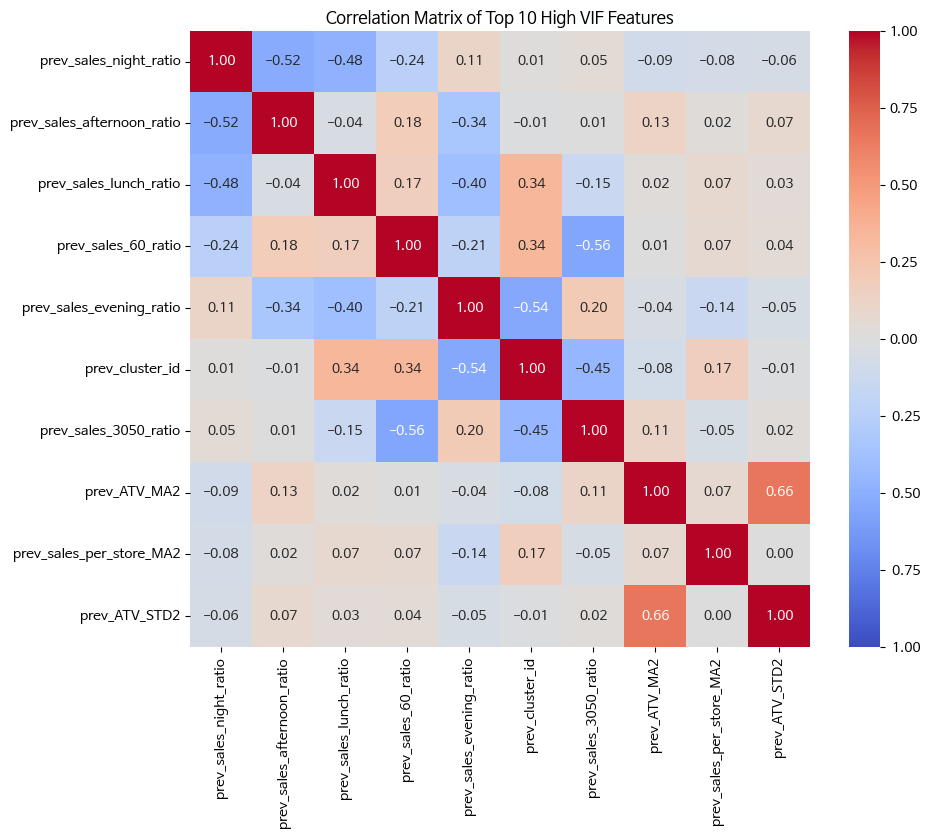

In [19]:
# 1. X_vif2에서 VIF 지수 높은 일부 피처 제거
passed_features3 = [
  'prev_wp_total_log', 'prev_rp_total_log', 'prev_apt_price_log',
  'prev_sales_weekend_ratio',
  'prev_sales_lunch_ratio', 'prev_sales_afternoon_ratio', 'prev_sales_evening_ratio', 'prev_sales_night_ratio',
  'prev_sales_2030_ratio', 'prev_sales_3050_ratio', 'prev_sales_60_ratio',
  'prev_edu_cnt', 'prev_traffic_score',
  'prev_cluster_id',

  # 시계열 파생 변수
   'prev_qs_total_log_MA2', 'prev_qs_total_log_STD2', 'prev_qs_total_log_QoQ',
   'prev_sales_per_store_MA2', 'prev_sales_per_store_STD2',
   'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_QoQ',
   'prev_fp_total_log_MA2', 'prev_fp_total_log_STD2', 'prev_fp_total_log_QoQ',
   'prev_store_density_MA2', 'prev_store_density_STD2', 'prev_store_density_QoQ',
]
X_vif3 = X_vif2[passed_features3].copy()

# 2. VIF 계산을 위한 전처리
# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif3.insert(0, 'const', 1.0)

# 3. VIF 계산
vif3_data = pd.DataFrame()
vif3_data["Feature"] = X_vif3.columns
vif3_data["VIF"] = [variance_inflation_factor(X_vif3.values, i) for i in range(X_vif3.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif3_data = vif3_data[vif3_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif3_data)

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif3_data['Feature'].head(10).tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(X_vif3[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

### 모델 학습

1. OOT 분할 및 다중 모델 베이스라인 평가


In [20]:
# 1. 모델 피처(X)와 타겟(y) 분리 (식별자 제거)
# 시간순으로 다시 한번 정렬.
final_features = passed_features3 + id_features + ['target']
df_model = df_temp[final_features].sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

drop_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target']
X = df_model.drop(columns=drop_cols)
y = df_model['target'].astype(int)

print(f"=== 데이터 준비 완료 (Shape: {X.shape}) ===")

# 2. GPU 지원 모델 세팅 (클래스 불균형 고려)
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        tree_method='hist', device='cuda', # GPU 세팅
        random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        device='gpu', # GPU 세팅 (코랩 환경에 따라 CPU로 돌아갈 수도 있음)
        class_weight='balanced', random_state=42,
        verbose=-1  # 지저분한 경고문 끄기
    ),
    'CatBoost': cb.CatBoostClassifier(
        loss_function='MultiClass',
        task_type='GPU', # GPU 세팅
        auto_class_weights='Balanced', random_state=42, verbose=0
    )
}

# 3. 시계열 교차 검증 (TimeSeriesSplit)
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# 결과를 저장할 딕셔너리
cv_results = {model_name: [] for model_name in models.keys()}

print("\n=== GPU 다중 모델 TimeSeriesSplit 평가 시작 ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\n[Fold {fold + 1}/{n_splits}]")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)

        # 검증셋 예측 및 성능 평가 (Macro F1)
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        cv_results[name].append(score)

        print(f" - {name} F1 Score: {score:.4f}")

# 4. 최종 베이스라인 결과 요약
print("\n=== 모델 베이스라인 평균 성능 ===")
for name, scores in cv_results.items():
    mean_score = np.mean(scores)
    print(f"[{name}] 평균 Macro F1: {mean_score:.4f} (Fold별: {[round(s, 4) for s in scores]})")

=== 데이터 준비 완료 (Shape: (385205, 28)) ===

=== GPU 다중 모델 TimeSeriesSplit 평가 시작 ===

[Fold 1/3]
 - XGBoost F1 Score: 0.5508
 - LightGBM F1 Score: 0.5667
 - CatBoost F1 Score: 0.5648

[Fold 2/3]
 - XGBoost F1 Score: 0.5521
 - LightGBM F1 Score: 0.5659
 - CatBoost F1 Score: 0.5665

[Fold 3/3]
 - XGBoost F1 Score: 0.5470
 - LightGBM F1 Score: 0.5681
 - CatBoost F1 Score: 0.5681

=== 모델 베이스라인 평균 성능 ===
[XGBoost] 평균 Macro F1: 0.5500 (Fold별: [0.5508, 0.5521, 0.547])
[LightGBM] 평균 Macro F1: 0.5669 (Fold별: [0.5667, 0.5659, 0.5681])
[CatBoost] 평균 Macro F1: 0.5665 (Fold별: [0.5648, 0.5665, 0.5681])


In [21]:
# -------------------------------------------------------------------
# [Step 1] OOT 데이터 분할 및 타겟/식별자 분리
# -------------------------------------------------------------------
# VIF 검사를 통과한 피처에 식별자와 타겟을 합쳐서 정렬 (passed_features3 사용)
final_features = passed_features3 + id_features + ['target']
df_model = df_temp[final_features].sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 시간 기준 분할: 가장 최근 1개 분기를 Test, 그 직전 1개 분기를 Val, 나머지를 Train으로 설정
unique_quarters = sorted(df_model['yqc_cd'].unique())
test_quarter = unique_quarters[-1]
val_quarter = unique_quarters[-2]

train_df = df_model[df_model['yqc_cd'] < val_quarter]
val_df = df_model[df_model['yqc_cd'] == val_quarter]
test_df = df_model[df_model['yqc_cd'] == test_quarter]

drop_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target'].astype(int)
X_val = val_df.drop(columns=drop_cols)
y_val = val_df['target'].astype(int)
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target'].astype(int)

print(f"=== 데이터 분할 완료 ===")
print(f"Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

# TimeSeriesSplit 설정 (Optuna 검증용)
tscv = TimeSeriesSplit(n_splits=3)

=== 데이터 분할 완료 ===
Train(351703), Val(16784), Test(16718)


In [22]:
# -------------------------------------------------------------------
# [Step 2] Optuna 기반 LightGBM 정밀 튜닝
# -------------------------------------------------------------------
print("\n=== LightGBM Optuna 튜닝 시작 ===")
def lgb_objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'class_weight': 'balanced',
        'device_type': 'gpu',
        'random_state': 42,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }

    cv_scores = []
    for tr_idx, v_idx in tscv.split(X_train):
        X_tr, X_v = X_train.iloc[tr_idx], X_train.iloc[v_idx]
        y_tr, y_v = y_train.iloc[tr_idx], y_train.iloc[v_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    return np.mean(cv_scores)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=False)
best_lgb_params = lgb_study.best_params

[I 2026-04-17 16:44:12,649] A new study created in memory with name: no-name-9c4eb3e1-0d5a-4fc1-95a7-09fe67839398



=== LightGBM Optuna 튜닝 시작 ===


[I 2026-04-17 16:45:17,852] Trial 0 finished with value: 0.5682328247952273 and parameters: {'n_estimators': 542, 'learning_rate': 0.060593716601483195, 'max_depth': 8, 'num_leaves': 97, 'min_child_samples': 72, 'subsample': 0.8595800309126416, 'colsample_bytree': 0.8066442344413615, 'reg_alpha': 0.011259472114118462, 'reg_lambda': 0.0035739748477780476}. Best is trial 0 with value: 0.5682328247952273.
[I 2026-04-17 16:46:40,173] Trial 1 finished with value: 0.5688345385340097 and parameters: {'n_estimators': 652, 'learning_rate': 0.015093081472715741, 'max_depth': 9, 'num_leaves': 83, 'min_child_samples': 46, 'subsample': 0.6450206056238731, 'colsample_bytree': 0.8597005027923035, 'reg_alpha': 0.09568867778747744, 'reg_lambda': 0.056724828341902615}. Best is trial 1 with value: 0.5688345385340097.
[I 2026-04-17 16:47:39,650] Trial 2 finished with value: 0.5654535895123519 and parameters: {'n_estimators': 782, 'learning_rate': 0.010374352542254975, 'max_depth': 9, 'num_leaves': 32, 'mi

In [26]:
# 1. 튜닝 결과 및 파라미터 출력
print(f"\n[LightGBM 튜닝 완료]")
print(f"Best CV Macro F1: {lgb_study.best_value:.4f}")
print("Best Parameters:")
for key, value in best_lgb_params.items():
    print(f"  - {key}: {value}")

# 2. 단일 모델 과적합 1차 점검 (Train vs Val)
print("\n[LightGBM 단일 모델 과적합 1차 점검]")
# 찾은 최적 파라미터로 임시 모델을 만들어 전체 Train 셋에 학습
temp_lgb = lgb.LGBMClassifier(
    **best_lgb_params,
    objective='multiclass',
    class_weight='balanced',
    device_type='gpu',
    random_state=42,
    verbose=-1)
temp_lgb.fit(X_train, y_train)

# Train과 Val 각각의 예측값 추출
train_preds_lgb = temp_lgb.predict(X_train)
val_preds_lgb = temp_lgb.predict(X_val)

# 점수 비교
print(f" - Train F1 Score : {f1_score(y_train, train_preds_lgb, average='macro'):.4f}")
print(f" - Val F1 Score   : {f1_score(y_val, val_preds_lgb, average='macro'):.4f}")


[LightGBM 튜닝 완료]
Best CV Macro F1: 0.5709
Best Parameters:
  - n_estimators: 659
  - learning_rate: 0.024497775481292314
  - max_depth: 10
  - num_leaves: 122
  - min_child_samples: 20
  - subsample: 0.6114214574500069
  - colsample_bytree: 0.8679936764468301
  - reg_alpha: 1.7096764085853253
  - reg_lambda: 0.14267642851287363

[LightGBM 단일 모델 과적합 1차 점검]
 - Train F1 Score : 0.6294
 - Val F1 Score   : 0.5896


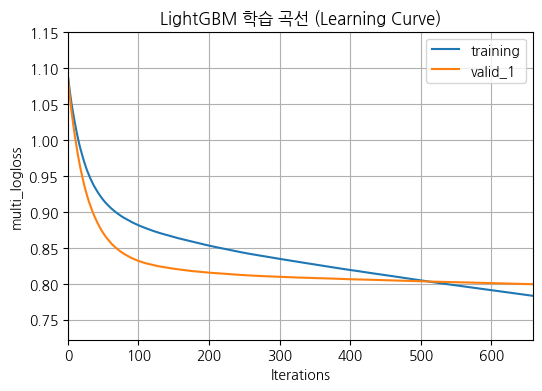

In [32]:
# 1. 모델 학습 시 eval_set을 지정해 기록을 남김
temp_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='multi_logloss'
)

# 2. 내장 함수로 학습 곡선 바로 그리기
lgb.plot_metric(temp_lgb, metric='multi_logloss', figsize=(6, 4))
plt.title('LightGBM 학습 곡선 (Learning Curve)')
plt.show()

In [23]:
# -------------------------------------------------------------------
# [Step 3] Optuna 기반 CatBoost 정밀 튜닝
# -------------------------------------------------------------------
print("\n=== CatBoost Optuna 튜닝 시작 ===")
def cat_objective(trial):
    params = {
        'loss_function': 'MultiClass',
        'task_type': 'GPU',
        'auto_class_weights': 'Balanced',
        'random_state': 42,
        'verbose': 0,
        'iterations': trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True)
    }

    cv_scores = []
    for tr_idx, v_idx in tscv.split(X_train):
        X_tr, X_v = X_train.iloc[tr_idx], X_train.iloc[v_idx]
        y_tr, y_v = y_train.iloc[tr_idx], y_train.iloc[v_idx]

        model = cb.CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    return np.mean(cv_scores)

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=30, show_progress_bar=False)
best_cat_params = cat_study.best_params

[I 2026-04-17 17:21:43,564] A new study created in memory with name: no-name-4c6349c7-91d8-405a-9801-11f2ed5b6aaf



=== CatBoost Optuna 튜닝 시작 ===


[I 2026-04-17 17:21:52,944] Trial 0 finished with value: 0.5646580023824347 and parameters: {'iterations': 287, 'learning_rate': 0.049806967596543066, 'depth': 6, 'l2_leaf_reg': 0.18560193475084513, 'random_strength': 0.01473491509541696}. Best is trial 0 with value: 0.5646580023824347.
[I 2026-04-17 17:22:07,740] Trial 1 finished with value: 0.5632576732864307 and parameters: {'iterations': 636, 'learning_rate': 0.023966158881924278, 'depth': 5, 'l2_leaf_reg': 0.032057773614110316, 'random_strength': 0.0021310459160967703}. Best is trial 0 with value: 0.5646580023824347.
[I 2026-04-17 17:22:18,698] Trial 2 finished with value: 0.5613266816361823 and parameters: {'iterations': 337, 'learning_rate': 0.02896209222115379, 'depth': 5, 'l2_leaf_reg': 4.490653040336352, 'random_strength': 0.16889200671588966}. Best is trial 0 with value: 0.5646580023824347.
[I 2026-04-17 17:22:29,991] Trial 3 finished with value: 0.5590483115901096 and parameters: {'iterations': 348, 'learning_rate': 0.01826

In [27]:
# 1. 튜닝 결과 및 파라미터 출력
print(f"\n[CatBoost 튜닝 완료]")
print(f"Best CV Macro F1: {cat_study.best_value:.4f}")
print("Best Parameters:")
for key, value in best_cat_params.items():
    print(f"  - {key}: {value}")

# 2. 단일 모델 과적합 1차 점검 (Train vs Val)
print("\n[CatBoost 단일 모델 과적합 1차 점검]")
# 찾은 최적 파라미터로 임시 모델을 만들어 전체 Train 셋에 학습
temp_cat = cb.CatBoostClassifier(**best_cat_params,
    loss_function='MultiClass',
    task_type='GPU',
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0)
temp_cat.fit(X_train, y_train)

# Train과 Val 각각의 예측값 추출
train_preds_cat = temp_cat.predict(X_train)
val_preds_cat = temp_cat.predict(X_val)

# 점수 비교
print(f" - Train F1 Score : {f1_score(y_train, train_preds_cat, average='macro'):.4f}")
print(f" - Val F1 Score   : {f1_score(y_val, val_preds_cat, average='macro'):.4f}")


[CatBoost 튜닝 완료]
Best CV Macro F1: 0.5694
Best Parameters:
  - iterations: 799
  - learning_rate: 0.06720657883582584
  - depth: 7
  - l2_leaf_reg: 0.61644889630623
  - random_strength: 6.61819726388938

[CatBoost 단일 모델 과적합 1차 점검]
 - Train F1 Score : 0.5949
 - Val F1 Score   : 0.5860


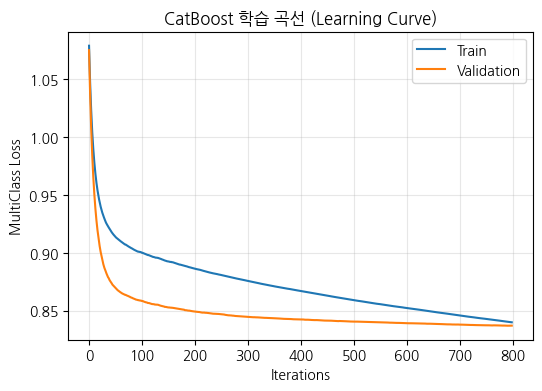

In [35]:
# 1. CatBoost 학습 (기록을 위해 eval_set 추가)
# CatBoost는 기본적으로 MultiClass 손실을 기록하므로 eval_metric은 생략 가능, eval_set에는 검증 데이터 하나만
temp_cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val), # 리스트가 아니라 튜플 하나만 전달
    verbose=0
)

# 2. 학습 결과 데이터 추출
evals_result = temp_cat.get_evals_result()

# CatBoost는 eval_set에 안 넣어도 'learn'과 'validation'이라는 키로 데이터를 저장함
train_loss = evals_result['learn']['MultiClass']
val_loss = evals_result['validation']['MultiClass']

# 3. Matplotlib으로 직접 시각화
plt.figure(figsize=(6, 4))
plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')

plt.title('CatBoost 학습 곡선 (Learning Curve)')
plt.xlabel('Iterations')
plt.ylabel('MultiClass Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# -------------------------------------------------------------------
# [Step 4] 앙상블 가중치 산출 및 과적합 점검
# -------------------------------------------------------------------
print("\n=== 최적 앙상블 비율 산출 및 과적합 점검 ===")

# 최고 성능의 파라미터로 Train 셋 전체 학습 (가중치 탐색용)
final_lgb = lgb.LGBMClassifier(**best_lgb_params, objective='multiclass', class_weight='balanced', device_type='gpu', random_state=42, verbose=-1)
final_cat = cb.CatBoostClassifier(**best_cat_params, loss_function='MultiClass', task_type='GPU', auto_class_weights='Balanced', random_state=42, verbose=0)

final_lgb.fit(X_train, y_train)
final_cat.fit(X_train, y_train)

# 검증셋(Val)을 활용하여 데이터 누수 없이 최적 가중치 탐색
val_prob_lgb = final_lgb.predict_proba(X_val)
val_prob_cat = final_cat.predict_proba(X_val)

def f1_loss(weights):
    weights = np.array(weights) / np.sum(weights)
    blended_prob = (weights[0] * val_prob_lgb) + (weights[1] * val_prob_cat)
    blended_preds = np.argmax(blended_prob, axis=1)
    return -f1_score(y_val, blended_preds, average='macro')

res = minimize(f1_loss, [0.5, 0.5], bounds=[(0.0, 1.0), (0.0, 1.0)], method='Nelder-Mead')
opt_weights = res.x / np.sum(res.x)

print(f"산출된 최적 가중치 -> LightGBM : CatBoost = {opt_weights[0]:.3f} : {opt_weights[1]:.3f}")

# 과적합 체크를 위한 Train / Val 점수 산출
train_prob = (opt_weights[0] * final_lgb.predict_proba(X_train)) + (opt_weights[1] * final_cat.predict_proba(X_train))
train_preds = np.argmax(train_prob, axis=1)
train_f1 = f1_score(y_train, train_preds, average='macro')

val_prob = (opt_weights[0] * val_prob_lgb) + (opt_weights[1] * val_prob_cat)
val_preds = np.argmax(val_prob, axis=1)
val_f1 = f1_score(y_val, val_preds, average='macro')


=== 최적 앙상블 비율 산출 및 과적합 점검 ===
산출된 최적 가중치 -> LightGBM : CatBoost = 0.459 : 0.541


In [25]:
# -------------------------------------------------------------------
# [Step 5] 전체 데이터 재학습(Retrain) 및 최종 평가 (OOT)
# -------------------------------------------------------------------
print("\n=== 최종 미래(Test) 예측 전, 모델 최신화(Train+Val 재학습) 진행 ===")
# Val 데이터의 최신 패턴까지 모두 학습시키기 위해 데이터 통합
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_lgb.fit(X_train_full, y_train_full)
final_cat.fit(X_train_full, y_train_full)

# Test 셋에 최종 앙상블 적용
test_prob_lgb = final_lgb.predict_proba(X_test)
test_prob_cat = final_cat.predict_proba(X_test)

final_prob = (opt_weights[0] * test_prob_lgb) + (opt_weights[1] * test_prob_cat)
final_preds = np.argmax(final_prob, axis=1)
test_f1 = f1_score(y_test, final_preds, average='macro')

print("\n========================================================")
print("             [최종 앙상블 성능 평가 리포트]             ")
print("========================================================")

print(f"1) 과적합 모니터링 (Macro F1)")
print(f"   - Train Score : {train_f1:.4f}")
print(f"   - Val Score   : {val_f1:.4f}")
print(f"   - Test Score  : {test_f1:.4f} (최종 OOT 성적)")

# ROC-AUC 계산 (OvR 방식 적용)
roc_auc = roc_auc_score(y_test, final_prob, multi_class='ovr', average='macro')
print(f"\n2) Multi-class ROC-AUC (OvR) : {roc_auc:.4f}")

print("\n3) Confusion Matrix (혼동 행렬)")
conf_mat = confusion_matrix(y_test, final_preds)
display(pd.DataFrame(conf_mat,
                     index=["실제:위축(0)", "실제:유지(1)", "실제:성장(2)"],
                     columns=["예측:위축(0)", "예측:유지(1)", "예측:성장(2)"]))


=== 최종 미래(Test) 예측 전, 모델 최신화(Train+Val 재학습) 진행 ===

             [최종 앙상블 성능 평가 리포트]             
1) 과적합 모니터링 (Macro F1)
   - Train Score : 0.6116
   - Val Score   : 0.5893
   - Test Score  : 0.5855 (최종 OOT 성적)

2) Multi-class ROC-AUC (OvR) : 0.8036

3) Confusion Matrix (혼동 행렬)


,예측:위축(0),예측:유지(1),예측:성장(2)
실제:위축(0),1485,596,745
실제:유지(1),1402,6737,1849
실제:성장(2),703,749,2452


Classification Report

In [36]:
print(f"\n Final Ensemble Macro F1 Score: {test_f1:.4f}")
print("\n[최종 앙상블 분류 리포트]")
print(classification_report(y_test, final_preds, target_names=["위축형(0)", "유지형(1)", "성장형(2)"]))


 Final Ensemble Macro F1 Score: 0.5855

[최종 앙상블 분류 리포트]
              precision    recall  f1-score   support

      위축형(0)       0.41      0.53      0.46      2826
      유지형(1)       0.83      0.67      0.75      9988
      성장형(2)       0.49      0.63      0.55      3904

    accuracy                           0.64     16718
   macro avg       0.58      0.61      0.59     16718
weighted avg       0.68      0.64      0.65     16718



#### ROC 곡선
다중 분류(Multi-class) -> OvR(One-vs-Rest) 방식 적용

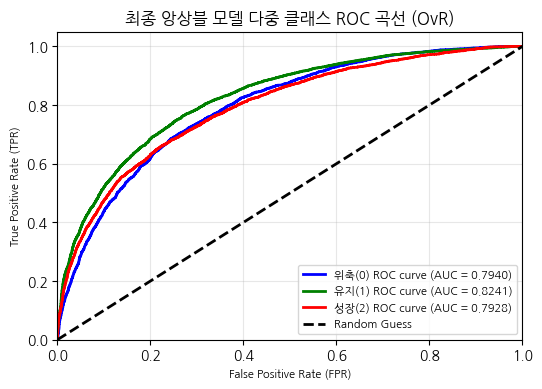

In [30]:
from sklearn.metrics import roc_curve, auc

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 클래스 정보 세팅
n_classes = 3
class_names = ['위축(0)', '유지(1)', '성장(2)']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(6, 4))

# 2. 클래스별로 ROC 곡선 및 AUC 계산 (One-vs-Rest)
for i in range(n_classes):
    # 실제 정답이 i인 것을 1, 나머지를 0으로 변환하여 계산
    fpr, tpr, _ = roc_curve(y_test == i, final_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{class_names[i]} ROC curve (AUC = {roc_auc:.4f})')

# 3. 랜덤 모델 기준선 (대각선) 추가
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

# 4. 그래프 꾸미기
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=8)
plt.ylabel('True Positive Rate (TPR)', fontsize=8)
plt.title('최종 앙상블 모델 다중 클래스 ROC 곡선 (OvR)', fontsize=12)
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

#### [최종 앙상블 모델 ROC 곡선 분석 요약]

1. 전반적 성능 평가

3개 클래스의 ROC 곡선 모두 랜덤 모델 기준선(검은 점선, AUC 0.5)을 크게 상회하며 좌측 상단으로 뚜렷하게 굽어 있다.

이는 모델이 단순 운에 의존하거나 한 클래스로 밀어붙이지 않고, 상권의 위축/유지/성장 상태를 명확하게 구분해 내는 변별력을 갖췄음을 시각적으로 증명한다.

<br>

2. 클래스별 변별력 (AUC 스코어)

유지(1, 초록색) - AUC 0.8241: 가장 높은 예측력을 보인다. 상권 데이터의 대다수를 차지하는 다수 클래스이므로, 모델이 정상 유지 상태의 패턴을 가장 안정적으로 학습했음을 의미한다.

위축(0, 파란색) - AUC 0.7940 / 성장(2, 빨간색) - AUC 0.7928: 데이터 비율이 적은 소수 클래스임에도 불구하고 모두 AUC 0.8에 근접한 준수한 방어력을 기록했다. 위축과 성장 상권을 판별하는 모델의 난이도나 정확도는 거의 동일하게 나타난다.

<br>

3. 종합 해석

결과적으로 극심한 클래스 불균형 환경에서도 핵심 타겟인 소수 클래스(성장, 위축)의 예측력이 무너지지 않았다. 앞서 파이프라인에 세팅했던 가중치 조절(class_weight)과 모델 앙상블 전략이 성공적으로 작동하여 모델의 균형감을 훌륭하게 잡아냈음을 보여주는 지표다.

Confusion Matrix

=== 1. 최종 앙상블 모델 Confusion Matrix ===


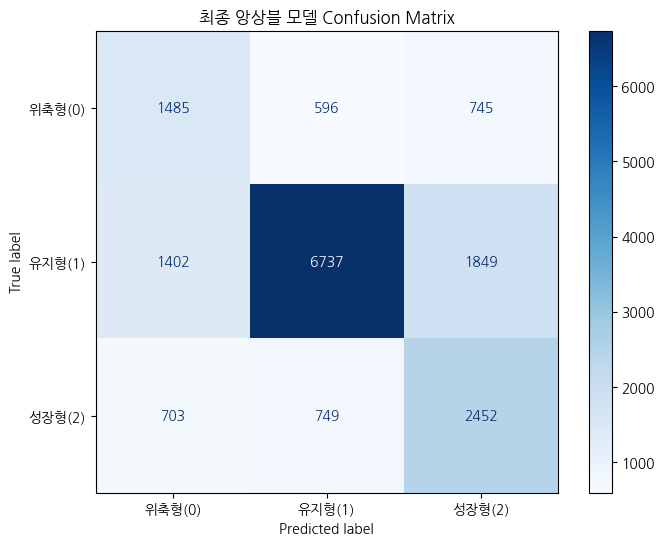

In [39]:
# 한글 폰트 및 마이너스 기호 설정 (이전 설정 유지)
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# [1] 앙상블 모델 오답 노트 (Confusion Matrix)
# ==========================================
print("=== 1. 최종 앙상블 모델 Confusion Matrix ===")
cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["위축형(0)", "유지형(1)", "성장형(2)"])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('최종 앙상블 모델 Confusion Matrix', fontsize=12)
plt.show()

Feature Importance


=== 2. LightGBM vs CatBoost 변수 중요도 비교 ===


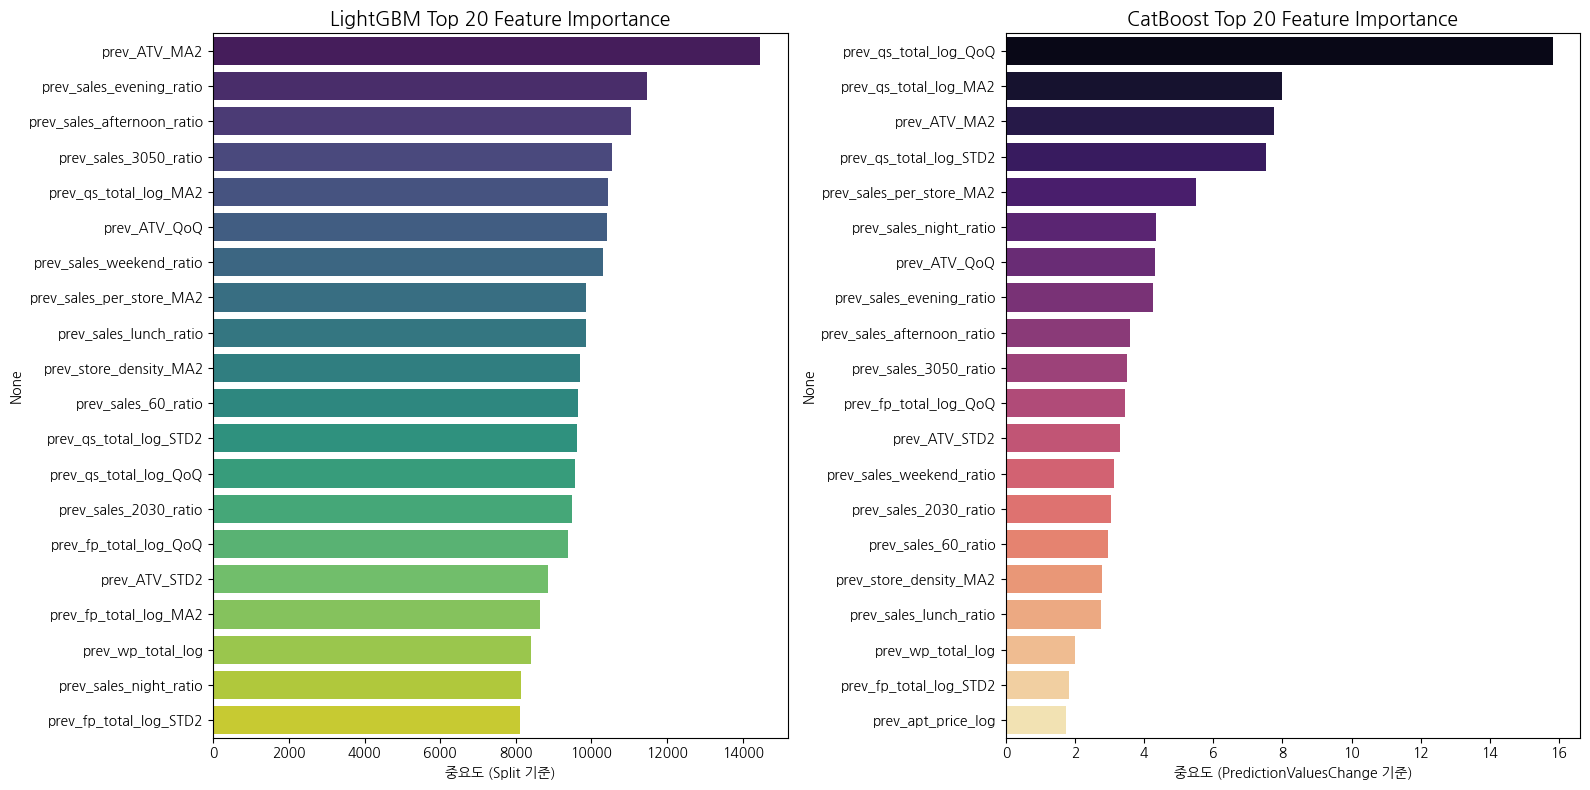

In [44]:
# ==========================================
# [2] 베이스 모델 Feature Importance 비교
# ==========================================
print("\n=== 2. LightGBM vs CatBoost 변수 중요도 비교 ===")

# LightGBM 변수 중요도 추출
lgb_importance = pd.Series(final_lgb.feature_importances_, index=X_train.columns)
lgb_top20 = lgb_importance.sort_values(ascending=False)[:20]

# CatBoost 변수 중요도 추출
cat_importance = pd.Series(final_cat.get_feature_importance(), index=X_train.columns)
cat_top20 = cat_importance.sort_values(ascending=False)[:20]

# 시각화 (두 모델 나란히 비교)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LightGBM 그래프
sns.barplot(x=lgb_top20, y=lgb_top20.index, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM Top 20 Feature Importance', fontsize=14)
axes[0].set_xlabel('중요도 (Split 기준)')

# CatBoost 그래프
sns.barplot(x=cat_top20, y=cat_top20.index, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost Top 20 Feature Importance', fontsize=14)
axes[1].set_xlabel('중요도 (PredictionValuesChange 기준)')

plt.tight_layout()
plt.show()

SHAP 분석

=== SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===


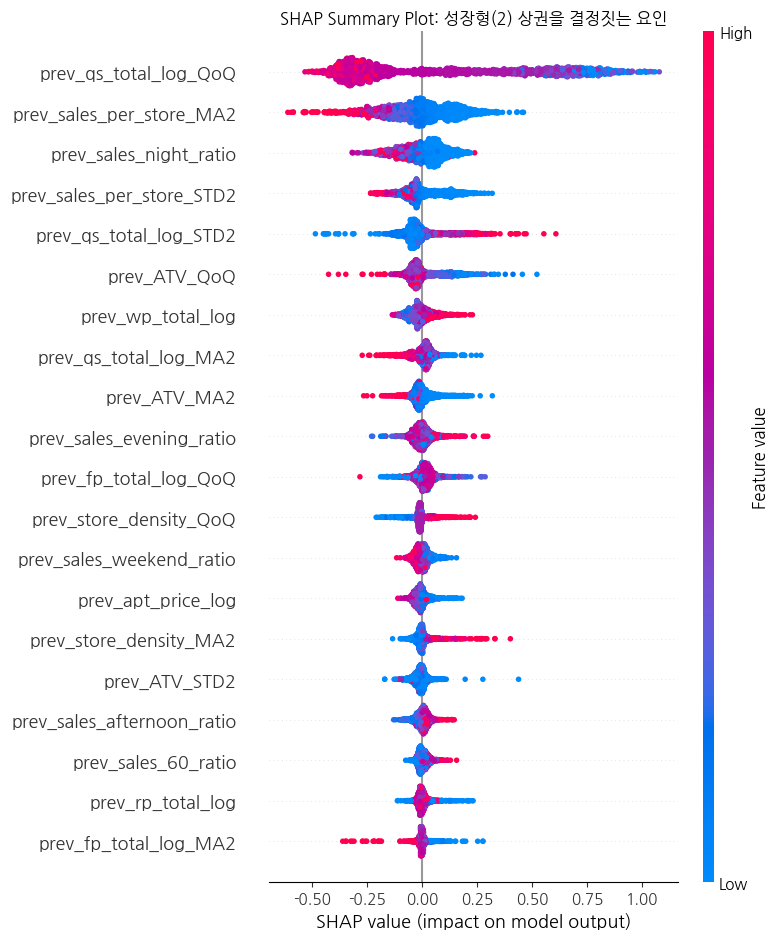

In [48]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정 (코랩 환경)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===")

# 1. SHAP TreeExplainer 초기화 (튜닝된 LightGBM 모델 사용)
explainer = shap.TreeExplainer(final_lgb)

# 2. 계산 속도를 위해 Test 셋에서 무작위로 2000개 샘플 추출
X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스(0:위축, 1:유지, 2:성장) 중 "2(성장형)"에 대한 SHAP 값 추출
# shap 버전이 최신일 경우 shap_values[:, :, 2] 형태로 인덱싱합니다. (구버전은 shap_values[2])
try:
    shap_values_target = shap_values[:, :, 2]
except IndexError:
    shap_values_target = shap_values[2]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(8, 4))
plt.title("SHAP Summary Plot: 성장형(2) 상권을 결정짓는 요인", fontsize=12)

# 빨간 점(Feature 값이 높을 때)과 파란 점(Feature 값이 낮을 때)이
# 오른쪽(성장 확률 증가)과 왼쪽(성장 확률 감소) 중 어디로 향하는지 보여주는 그래프
shap.summary_plot(shap_values_target, X_test_sample, show=False)

plt.tight_layout()
plt.show()

=== SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===


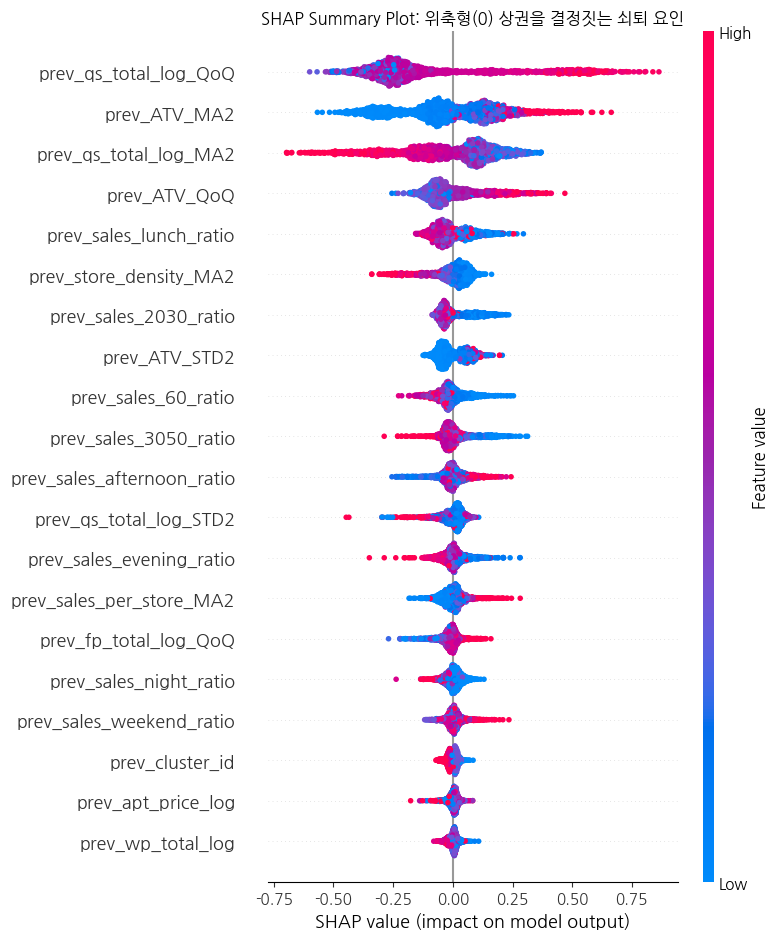

In [49]:
print("=== SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===")

# 1. SHAP TreeExplainer 초기화 (이미 되어있다면 생략 가능하지만 명확히 하기 위해 포함)
explainer = shap.TreeExplainer(final_lgb)

# 2. Test 셋에서 무작위로 샘플 추출
# X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스 중 "0(위축형)"에 대한 SHAP 값 추출
try:
    shap_values_shrink = shap_values[:, :, 0]
except IndexError:
    shap_values_shrink = shap_values[0]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(8, 4))
plt.title("SHAP Summary Plot: 위축형(0) 상권을 결정짓는 쇠퇴 요인", fontsize=12)

shap.summary_plot(shap_values_shrink, X_test_sample, show=False)

plt.tight_layout()
plt.show()

#### qs_total_log, prev_ATV의 Threshold 탐색

1. SHAP 의존성 플롯 (Dependence Plot) 그리기

<Figure size 700x500 with 0 Axes>

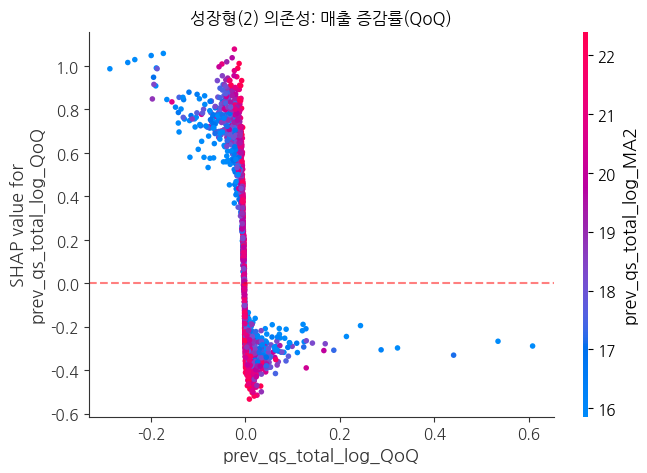

<Figure size 700x500 with 0 Axes>

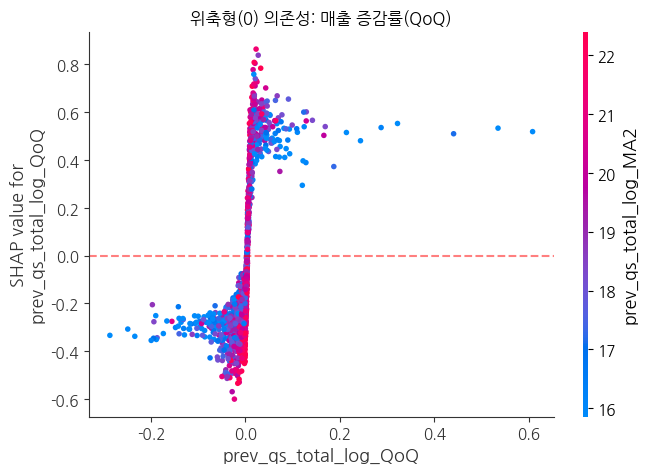

In [57]:
# ==========================================
# [1] 매출 증감률 (prev_qs_total_log_QoQ) 분석
# ==========================================
# 1-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_qs_total_log_QoQ', shap_values_target, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 매출 증감률(QoQ)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 1-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_qs_total_log_QoQ', shap_values_shrink, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 매출 증감률(QoQ)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

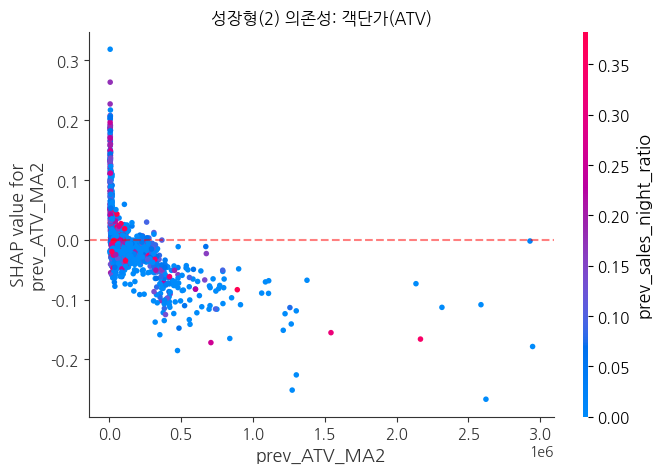

<Figure size 700x500 with 0 Axes>

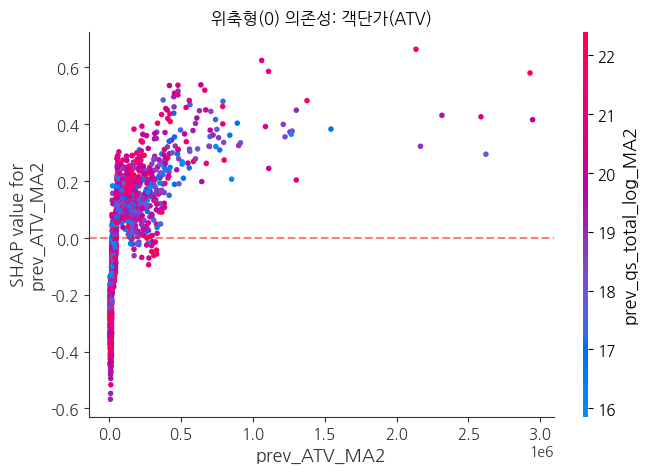

In [58]:
# ==========================================
# [2] 객단가 이동평균 (prev_ATV_MA2) 분석
# ==========================================
# 2-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_ATV_MA2', shap_values_target, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 객단가(ATV)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 2-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_ATV_MA2', shap_values_shrink, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 객단가(ATV)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

<Figure size 700x500 with 0 Axes>

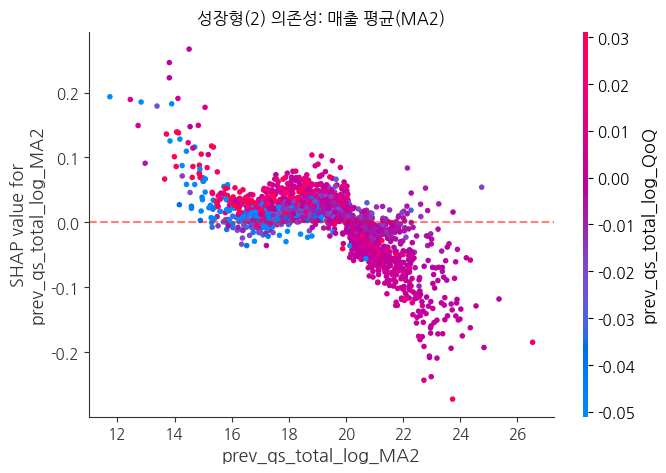

<Figure size 700x500 with 0 Axes>

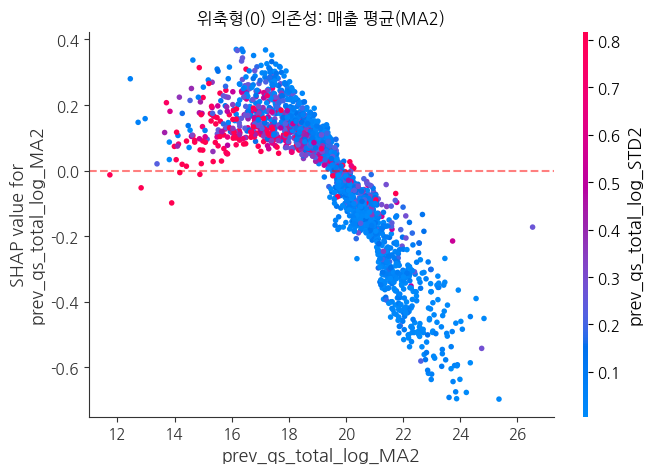

In [60]:
# ==========================================
# [3] 매출 이동평균 (prev_qs_total_log_MA2) 분석
# ==========================================
# 3-1. 성장형(2)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_qs_total_log_MA2', shap_values_target, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("성장형(2) 의존성: 매출 평균(MA2)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 3-2. 위축형(0)에 미치는 영향
plt.figure(figsize=(7, 5))
shap.dependence_plot('prev_qs_total_log_MA2', shap_values_shrink, X_test_sample,
                     interaction_index='auto', show=False)
plt.title("위축형(0) 의존성: 매출 평균(MA2)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

2. 직관적인 통계치 확인 (EDA 방식)

In [53]:
print("=== 클래스별 실제 객단가(ATV) 기초 통계 ===")
atv_stats = test_df.groupby('target')['prev_ATV_MA2'].agg(['mean', 'median', 'min', 'max']).round(0)
atv_stats.index = ['위축형(0)', '유지형(1)', '성장형(2)']
print(atv_stats)

=== 클래스별 실제 객단가(ATV) 기초 통계 ===
            mean   median     min        max
위축형(0)  202238.0  81441.0   750.0  8039040.0
유지형(1)   84718.0  31702.0   707.0  9750000.0
성장형(2)  123402.0  45502.0  1563.0  7340799.0


군집별 정답률(성능) 분석

In [66]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# 1. 결과 데이터프레임 생성 (실제값, 예측값, 군집ID 포함)
analysis_df = pd.DataFrame({
    'actual': y_test,
    'pred': final_preds,
    'cluster_id': test_df['prev_cluster_id'].values
})

# 2. 군집별 성능 저장할 리스트
cluster_perf = []

for cluster in sorted(analysis_df['cluster_id'].unique()):
    subset = analysis_df[analysis_df['cluster_id'] == cluster]

    f1 = f1_score(subset['actual'], subset['pred'], average='macro')
    acc = accuracy_score(subset['actual'], subset['pred'])

    # 특히 중요한 '성장형(2)'에 대한 Recall(재현율) 계산
    growth_actual = subset[subset['actual'] == 2]
    growth_recall = (growth_actual['actual'] == growth_actual['pred']).mean()

    cluster_perf.append({
        'Cluster': cluster,
        'Sample_Size': len(subset),
        'Accuracy': acc,
        'Macro_F1': f1,
        'Growth_Recall': growth_recall
    })

perf_df = pd.DataFrame(cluster_perf)
print("=== 군집별 모델 성능 비교 ===")
display(perf_df)

=== 군집별 모델 성능 비교 ===


,Cluster,Sample_Size,Accuracy,Macro_F1,Growth_Recall
0,0.0,2510,0.548207,0.545041,0.719101
1,1.0,6099,0.685522,0.595906,0.655825
2,2.0,2546,0.684603,0.519930,0.464387
3,3.0,5563,0.606507,0.583040,0.605721


#### 모델 저장

In [79]:
import joblib
import os

# 저장 폴더 생성
model_dir = 'seoul_commercial_model_final'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print(f"'{model_dir}' 폴더에 최종 결과물 저장")

try:
    # 1. 모델 저장
    joblib.dump(final_lgb, f'{model_dir}/lgb_model.pkl')
    final_cat.save_model(f'{model_dir}/cb_model.cbm')

    # 2. 전처리 및 군집화 객체 저장
    if 'scaler' in locals():
        joblib.dump(scaler, f'{model_dir}/scaler.pkl')
    if 'kmeans' in locals(): # K-Means 모델 변수명이 다르면 수정해
        joblib.dump(kmeans, f'{model_dir}/kmeans_model.pkl')

    # 3. 앙상블 설정 및 피처 리스트
    ensemble_config = {
        'weights': {'lgb': float(opt_weights[0]), 'cat': float(opt_weights[1])},
        'selected_features': list(X_test.columns),
        'id_features': id_features if 'id_features' in locals() else []
    }
    joblib.dump(ensemble_config, f'{model_dir}/ensemble_config.pkl')

    # 4. SHAP 데이터 및 객체 저장 (중복 제거 및 최적화)
    if isinstance(shap_values, list):
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[0], class1=shap_values[1], class2=shap_values[2])
    else:
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[:,:,0], class1=shap_values[:,:,1], class2=shap_values[:,:,2])

    joblib.dump(explainer, f'{model_dir}/shap_explainer.pkl')

    # 5. 전처리 완료된 데이터셋 저장
    # 런타임 다시 켜면 이것만 읽으면 전처리 셀 안 돌려도 됨
    df_model.to_pickle(f'{model_dir}/df_final.pkl')

    print("모든 객체(모델, 스케일러, 데이터셋, SHAP) 저장 성공.")

except Exception as e:
    print(f"[오류 발생] {e}")

'seoul_commercial_model_final' 폴더에 최종 결과물 저장
모든 객체(모델, 스케일러, 데이터셋, SHAP) 저장 성공.


In [80]:
import shutil
from google.colab import files

# 1. 'seoul_commercial_model_final' 폴더를 'seoul_model.zip'으로 압축
shutil.make_archive('seoul_model', 'zip', 'seoul_commercial_model_final')

# 2. 압축파일 다운로드
files.download('seoul_model.zip')

print("압축 및 다운로드 시작")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

압축 및 다운로드 시작
